<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/De_los_Reyes%2C_Jann_Moises_Nyll_Hands_on_Activity_3_3_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 3.2 Random Forest

Objective(s):

This activity aims to perform classification  using Random Forest

Intended Learning Outcomes (ILOs):
* Demonstrate how to build the model using Random Forest.
* Demonstrate how to evaluate the performance of the model.


Resources:
* Jupyter Notebook
* loan_data

Procedure:

We will use lending data from 2007-2010 and be trying to classify and predict whether or not the borrower paid back their loan in full.

Import the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Load the data and check the content of the dataframe using Pandas

In [ ]:
loans= pd.read_csv('/content/loan_data.csv')
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


Examine the data types.

In [ ]:
loans.dtypes

,0
credit.policy,int64
purpose,object
int.rate,float64
installment,float64
log.annual.inc,float64
dti,float64
fico,int64
days.with.cr.line,float64
revol.bal,int64
revol.util,float64


Create a histogram of two FICO distributions on top of each other, one for each credit.policy outcome.

Text(0.5, 0, 'FICO')

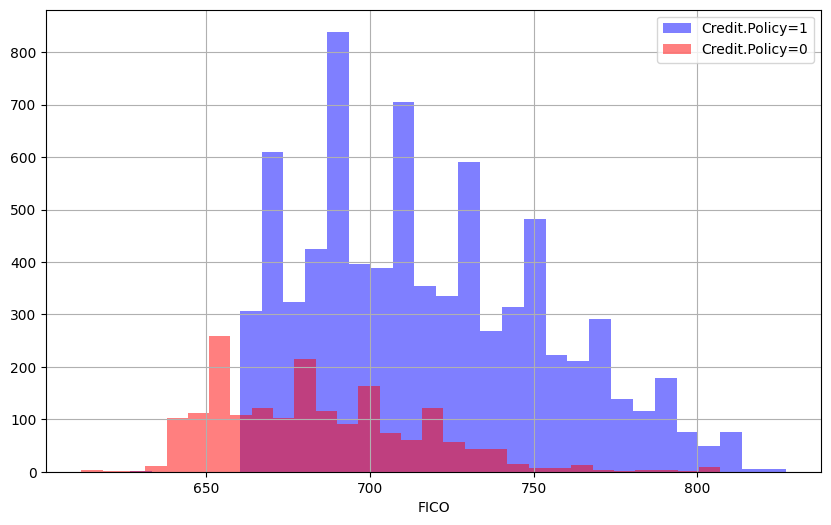

In [ ]:
plt.figure(figsize=(10,6))
loans[loans['credit.policy']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='Credit.Policy=1')
loans[loans['credit.policy']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='Credit.Policy=0')
plt.legend()
plt.xlabel('FICO')

Interpret the result of the graph

<font color =green> The graphs shows the comparison of FICO credit scores for two credit policy outcomes. In the graph we see that individual with credit policy equal to 1 are more frequent at higher FICO score  above 700. We can also see that individuals with credit policy outcomes equal to 0 are more frequent in below 700 FICO credit score. We can  also see that our distribution is skewed to the right. Upon analyzing the context of our model we may suggest that  individual with higher FICO score are more likelt assigned a credit policy of 1. We can also use this distribution to assess the risk of lending  to individuals which suggest that high FICO scores are less risky, thus more likely to have a favorable credit policy score.

Create a similar figure, except this time select by the not.fully.paid column.

Text(0.5, 0, 'FICO')

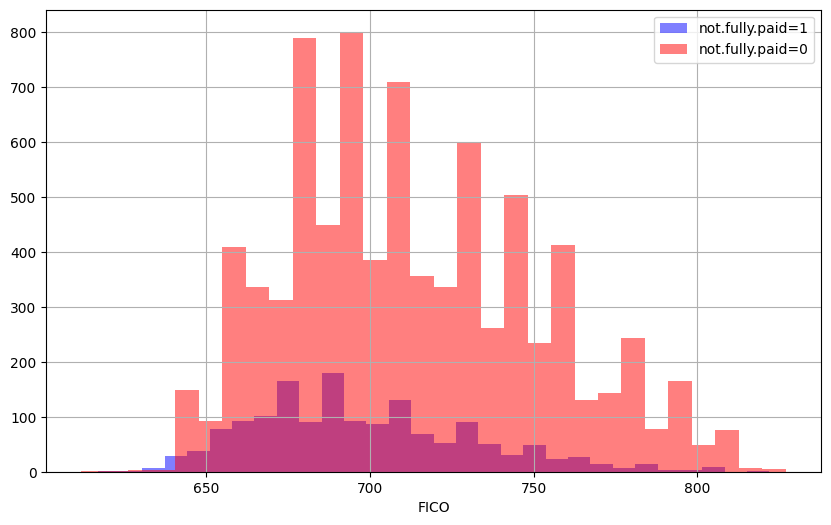

In [ ]:
plt.figure(figsize=(10,6))
loans[loans['not.fully.paid']==1]['fico'].hist(alpha=0.5,color='blue',
                                              bins=30,label='not.fully.paid=1')
loans[loans['not.fully.paid']==0]['fico'].hist(alpha=0.5,color='red',
                                              bins=30,label='not.fully.paid=0')
plt.legend()
plt.xlabel('FICO')

Interpret the result of the graph

<font color =green> In this distribution we notice that the distribution of our data are slightly skewed to the right. and they have multiple peaks. Most data appears to be more frequent at around 700 FICO credit score. We can observe that individuals who fully pay back their loan tend to have a high FICO score, we can interpret that FICO score could be an indicator of credit risk which can use by the lenders to assess the likelihood of borrowers repaying their loans. This could also valuable to the lenders for setting interest rates and credit decisions.

Create a countplot using seaborn showing the counts of loans by purpose, with the color hue defined by not.fully.paid.

<Axes: xlabel='purpose', ylabel='count'>

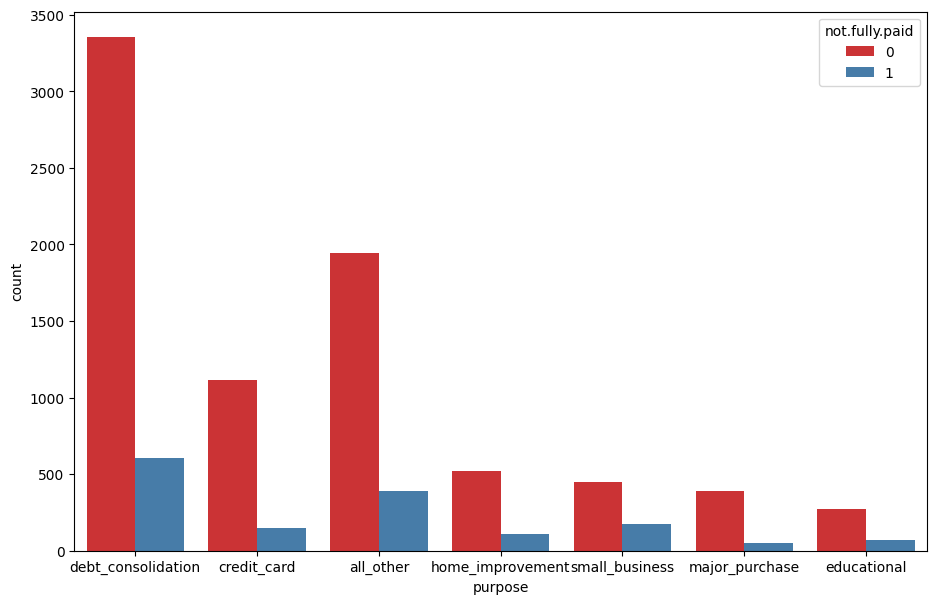

In [ ]:
plt.figure(figsize=(11,7))
sns.countplot(x='purpose',hue='not.fully.paid',data=loans,palette='Set1')

Interpret the result of the graph.

<font color =green> In this graph shows the counts of loan by purpose which provides insights into the relationship between the purpose of loan  and likelihood of  not being fully paid.
As we can see, the highest number in the countplot is the debt consolidation which is around 34000. Indentifying the purpose of loans which were not fully paid might indicate  higher risk of loan purposes.

Create the following lmplots to see if the trend differed between not.fully.paid and credit.policy.

<Figure size 1100x700 with 0 Axes>

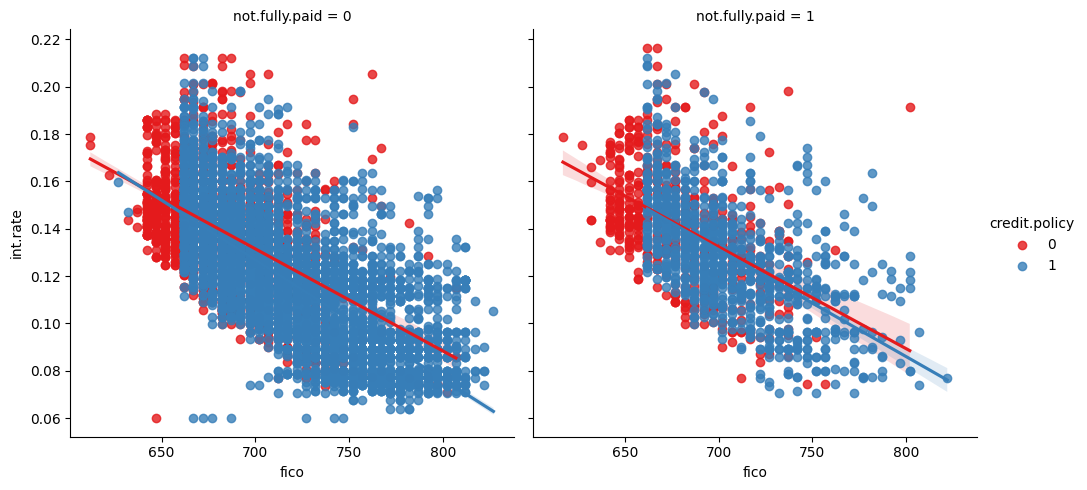

In [ ]:
plt.figure(figsize=(11,7))
sns.lmplot(y='int.rate',x='fico',data=loans,hue='credit.policy',
           col='not.fully.paid',palette='Set1')

Interpret the result of the graph

<font color="green"> As we observed in our graph, our trend tells that  theres  a negative correlation betweeen FICO and interest rate.This mean when our FICO credit score increases our interest rate tend to decreases which indicates that higher FICO score is less risky for lenders. We can also assess that individuals who have a history of not paying fully paid loans are much more risky for lenders,which leads to a higher interest rates.

The **purpose** column contains categorical value. Therefore, we need to transform the data using dummy variables.
otice that the **purpose** column as categorical



In [ ]:
cat_feats = ['purpose']

In [ ]:
final_data = pd.get_dummies(loans,columns=cat_feats,drop_first=True)

In [ ]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               9578 non-null   int64  
 1   int.rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log.annual.inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days.with.cr.line           9578 non-null   float64
 7   revol.bal                   9578 non-null   int64  
 8   revol.util                  9578 non-null   float64
 9   inq.last.6mths              9578 non-null   int64  
 10  delinq.2yrs                 9578 non-null   int64  
 11  pub.rec                     9578 non-null   int64  
 12  not.fully.paid              9578 non-null   int64  
 13  purpose_credit_card         9578 

Split the data into a training set and a testing set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = final_data.drop('not.fully.paid',axis=1)
y = final_data['not.fully.paid']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

Create an instance of the RandomForestClassifier class and fit it to our training data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(n_estimators=600)

In [ ]:
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=600)

What is n_estimators?

Type your answer here:

<font color = "green"> In machine learning, n_estimators is the number of trees to be used in RandomForestClassiier(). In our activity we initialize our n_estimator=600, does our model will be using and controlling only 600 trees during the proces since random forest is an ensemble method compromising of creating multiple decision tree. The number of trees we make will determine the performance of our model, does the more trees we make the better  performance it may gives but it will run slowly since it generate a lot of trees in the process.

Predict the class of not.fully.paid for the X_test data.

In [ ]:
predictions = rfc.predict(X_test)

Create a classification report from the results

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, roc_auc_score

In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.61      0.02      0.05       443

    accuracy                           0.85      2874
   macro avg       0.73      0.51      0.48      2874
weighted avg       0.81      0.85      0.78      2874



Show the Confusion Matrix for the predictions.

In [ ]:
print(confusion_matrix(y_test,predictions))

[[2424    7]
 [ 432   11]]


In [ ]:
#evaluate the performance using accuracy score
print(accuracy_score(y_test, predictions))

0.8472512178148921


In [ ]:
print(roc_auc_score(y_test, predictions))

0.5109756131532788


Interpret the result of the classification error, confusion matrix , accuracy score and roc_auc_score

<font color = "green" > Upon using the Random Forest we got a 0.8473 accuracy score in our testing data. In our confusion matrix, our model predicted  that 2424 loans that were fully paid is  correctly identified and about 11 loans were predicted correctly as  not fully paid. we also got a False negative we  around 432 and false positive which is  6. Our AUCROC got 0.51, which our model performance is not very good in distinguishing  loans that are fully paid  and those are not. This result may cause by the imbalance of each class, and need more tuning  and feature engineering for better  results.

Supplementary Activity:
* Choose your own dataset
* Import the dataset
* Determine the number of datapoints, columns and data types
* Remove unneccesary columns
* Do data cleaning such as removing empty values(NaN), replacing missing data .
* Perform descriptive statistics such as mean, median and mode
* Perform data visualization
* Build the model using Ranfom Forest
* Evaluate the model using classification report, accuracy , confusion matrix and roc_auc_score
* Change the n_estimators from 100 to 1000, increment by 100.
* Create a graph to compare the accuracy based from n_estimators

#About the dataset

[Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?resource=download&select=diabetes_binary_5050split_health_indicators_BRFSS2015.csv)

`diabetes _ binary _ 5050split _ health _ indicators _ BRFSS2015.csv` is a clean dataset of 70,692 survey responses to the CDC's BRFSS2015. It has an equal 50-50 split of respondents with no diabetes and with either prediabetes or diabetes. The target variable Diabetes_binary has 2 classes. 0 is for no diabetes, and 1 is for prediabetes or diabetes. This dataset has 21 feature variables and is balanced.

In [ ]:
#importing the dataset
data = pd.read_csv('/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
data.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


Determine the number of datapoints, columns and data types

In [ ]:
# Determine the number of datapoints, columns and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

Remove unneccesary columns

In [ ]:
# We dont have columns to be removed in this dataset.

Do data cleaning such as removing empty values(NaN), replacing missing data .

In [ ]:
data.isnull().sum() # We dont need to clean the data since we dont have empty values and missing data

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
data.isna().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
data.duplicated().sum()

1635

In [ ]:
#drop duplicates
data.drop_duplicates(inplace=True)

In [ ]:
# change each columns of the data data to int
data['Age']=data['Age'].astype('int64')
data['Education']=data['Education'].astype('int64')
data['Income']=data['Income'].astype('int64')
data['BMI']=data['BMI'].astype('int64')
data['CholCheck']=data['CholCheck'].astype('int64')
data['Smoker']=data['Smoker'].astype('int64')
data['Stroke']=data['Stroke'].astype('int64')
data['HeartDiseaseorAttack']=data['HeartDiseaseorAttack'].astype('int64')
data['PhysActivity']=data['PhysActivity'].astype('int64')
data['Fruits']=data['Fruits'].astype('int64')
data['Veggies']=data['Veggies'].astype('int64')
data['HvyAlcoholConsump']=data['HvyAlcoholConsump'].astype('int64')
data['AnyHealthcare']=data['AnyHealthcare'].astype('int64')
data['NoDocbcCost']=data['NoDocbcCost'].astype('int64')
data['GenHlth']=data['GenHlth'].astype('int64')
data['MentHlth']=data['MentHlth'].astype('int64')
data['PhysHlth']=data['PhysHlth'].astype('int64')
data['DiffWalk']=data['DiffWalk'].astype('int64')
data['Sex']=data['Sex'].astype('int64')
data['Diabetes_binary']=data['Diabetes_binary'].astype('int64')
data['HighBP']=data['HighBP'].astype('int64')
data['HighChol']=data['HighChol'].astype('int64')

In [ ]:
#showing all the columns of the data and its datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69057 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       69057 non-null  int64
 1   HighBP                69057 non-null  int64
 2   HighChol              69057 non-null  int64
 3   CholCheck             69057 non-null  int64
 4   BMI                   69057 non-null  int64
 5   Smoker                69057 non-null  int64
 6   Stroke                69057 non-null  int64
 7   HeartDiseaseorAttack  69057 non-null  int64
 8   PhysActivity          69057 non-null  int64
 9   Fruits                69057 non-null  int64
 10  Veggies               69057 non-null  int64
 11  HvyAlcoholConsump     69057 non-null  int64
 12  AnyHealthcare         69057 non-null  int64
 13  NoDocbcCost           69057 non-null  int64
 14  GenHlth               69057 non-null  int64
 15  MentHlth              69057 non-null  int64
 16  PhysHlth 

Perform descriptive statistics such as mean, median and mode

In [ ]:
# Calculate mean, median and mode.
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,69057.0,0.508232,0.499936,0.0,0.0,1.0,1.0,1.0
HighBP,69057.0,0.571224,0.494905,0.0,0.0,1.0,1.0,1.0
HighChol,69057.0,0.531329,0.499021,0.0,0.0,1.0,1.0,1.0
CholCheck,69057.0,0.974803,0.156723,0.0,1.0,1.0,1.0,1.0
BMI,69057.0,29.955834,7.147972,12.0,25.0,29.0,33.0,98.0
Smoker,69057.0,0.481935,0.499677,0.0,0.0,0.0,1.0,1.0
Stroke,69057.0,0.063643,0.244118,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,69057.0,0.150875,0.357930,0.0,0.0,0.0,0.0,1.0
PhysActivity,69057.0,0.696483,0.459780,0.0,0.0,1.0,1.0,1.0
Fruits,69057.0,0.605659,0.488712,0.0,0.0,1.0,1.0,1.0


In [ ]:
data = data.rename(columns={'Diabetes_binary': 'Diabetes'})

In [ ]:
#reindex the columns
data=data.reindex(columns=[ 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income','Diabetes'])

# Data Visualization
Perform data visualization

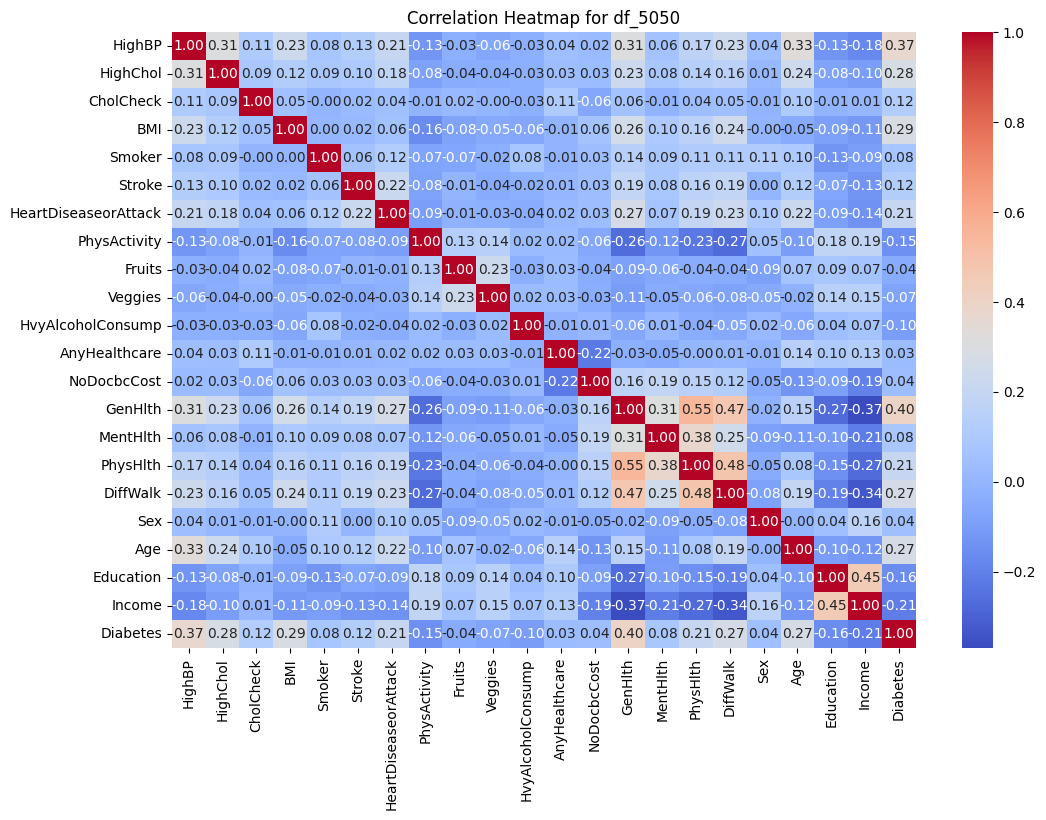

In [ ]:
#Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for df_5050')
plt.show()

In [ ]:
data['Diabetes'].value_counts()

,count
Diabetes,
1,35097
0,33960


<ipython-input-73-e44e36408c62>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])


Text(0.5, 0, 'Gender')

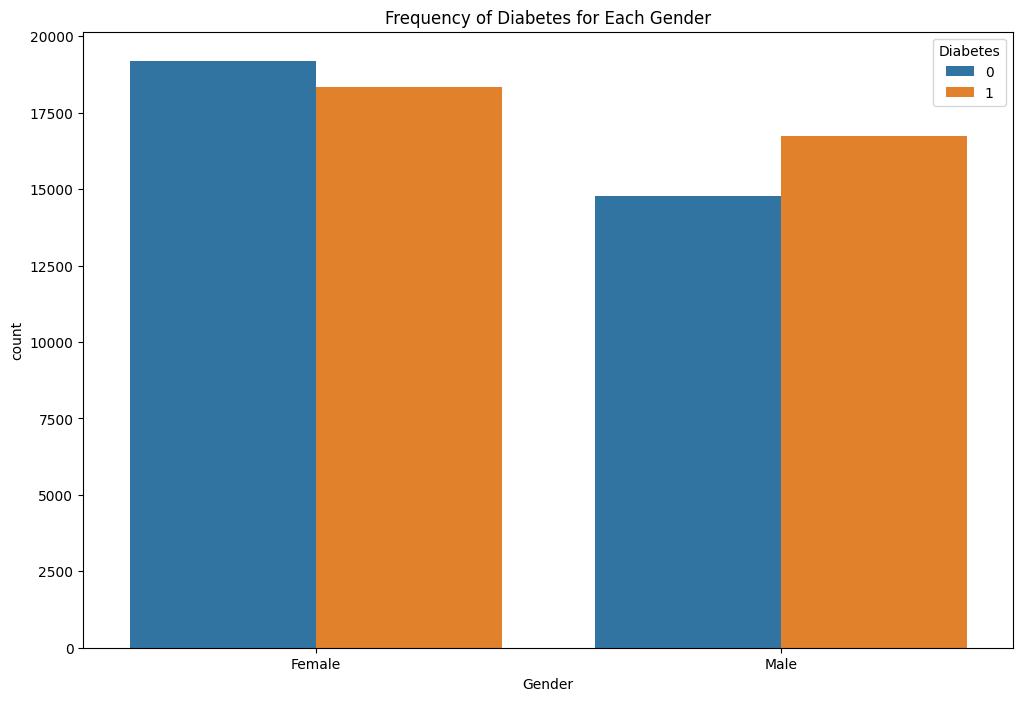

In [ ]:
#Frequency of diabetes for each gender 1
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='Sex', hue='Diabetes', data=data)
ax.set_xticklabels(['Female', 'Male'])
plt.title('Frequency of Diabetes for Each Gender')
plt.xlabel('Gender')

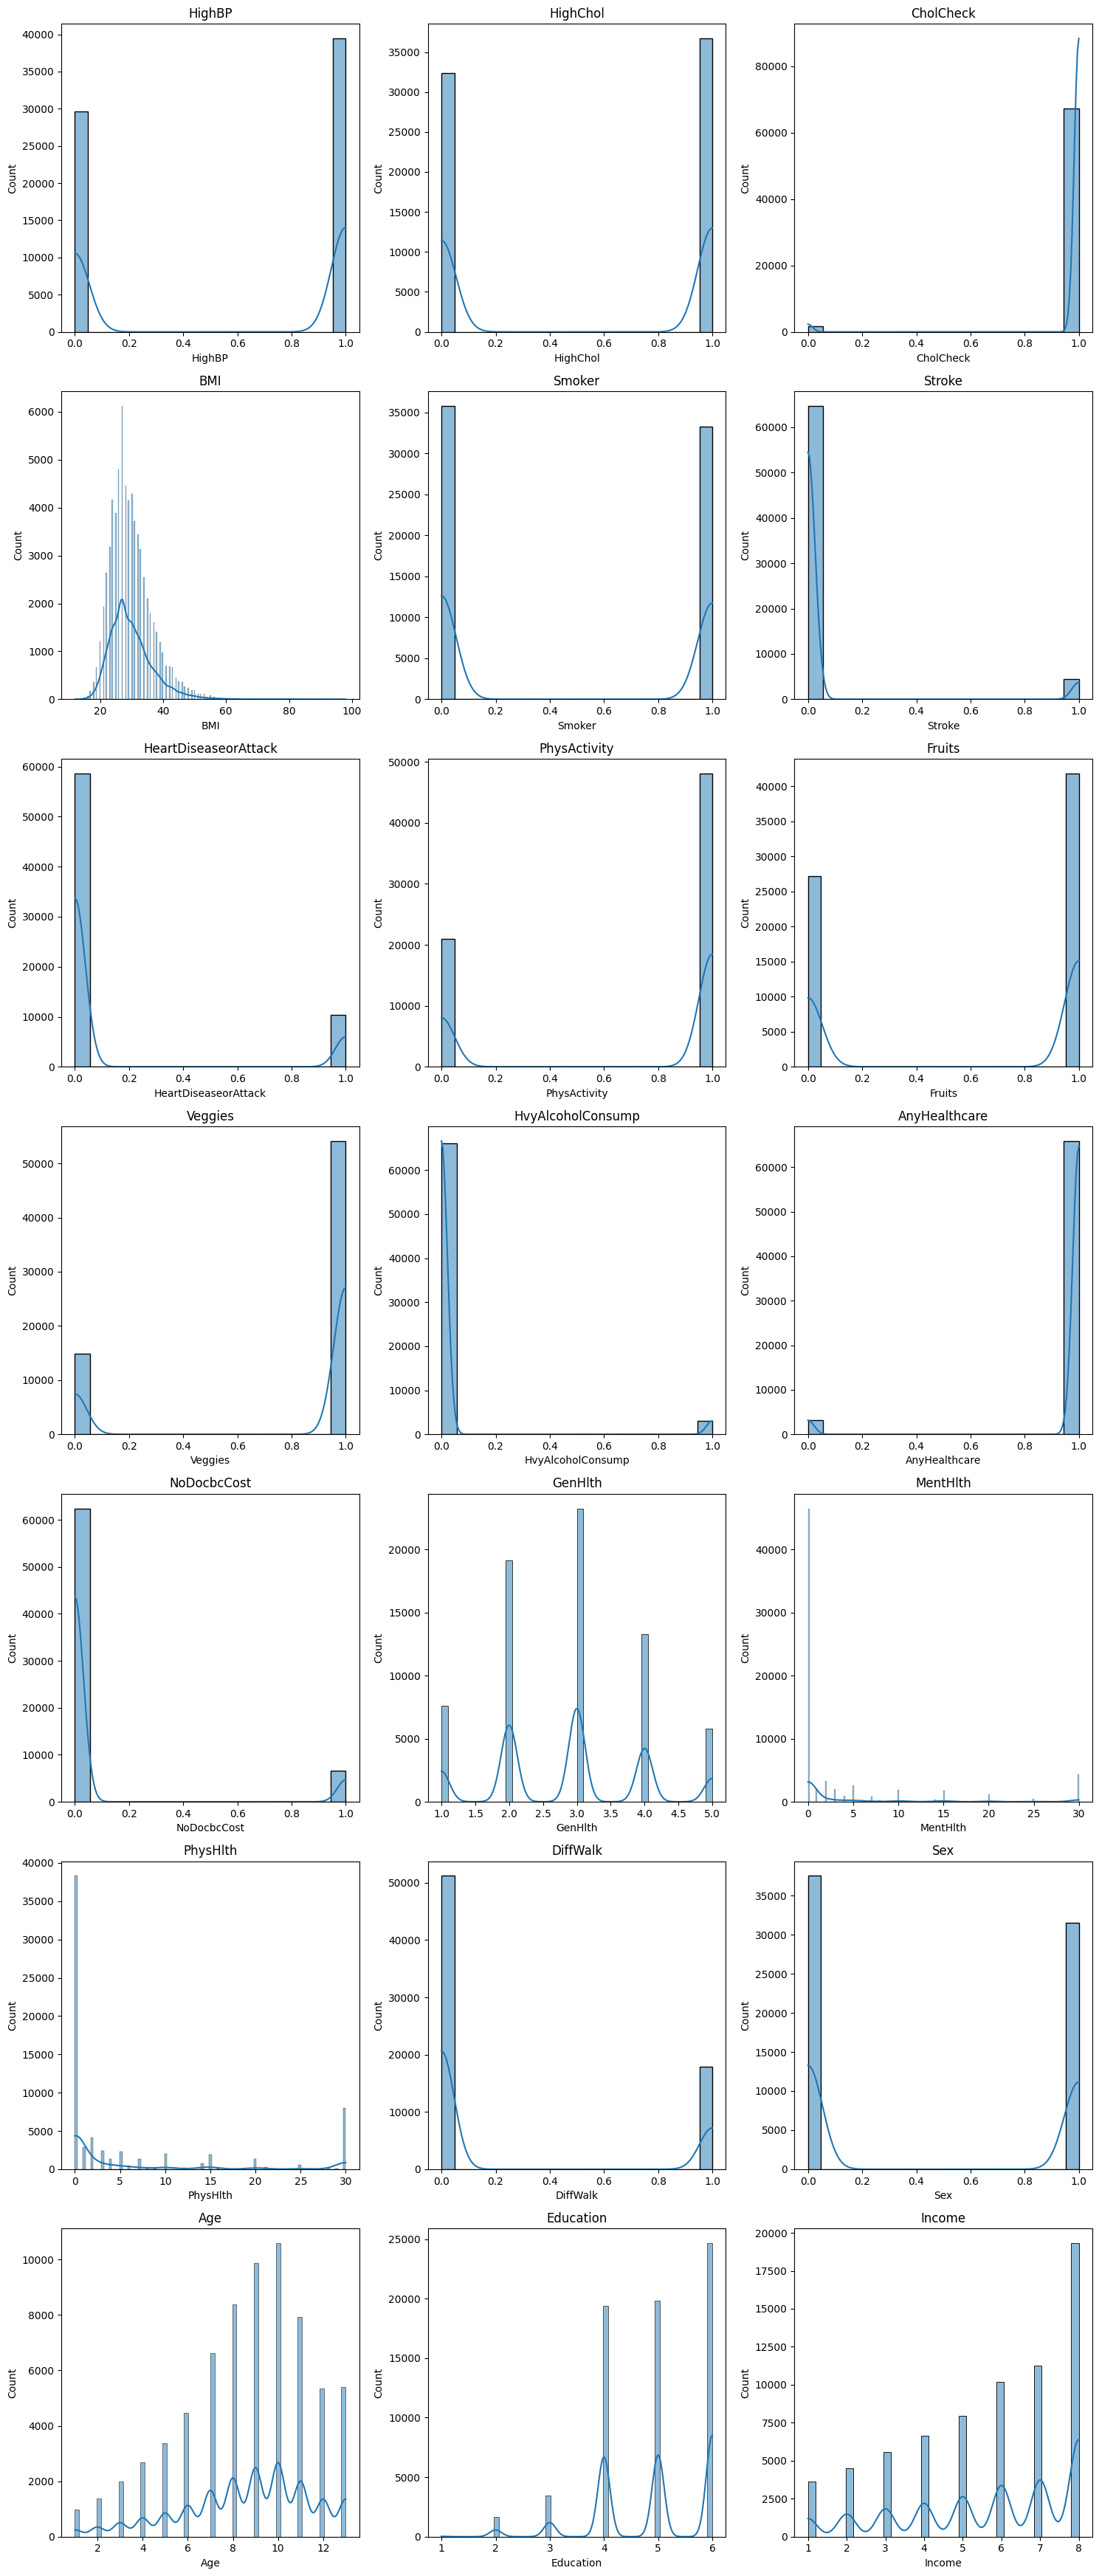

In [ ]:
import math

num_cols = len(data.columns[:-1])
num_rows = math.ceil(num_cols / 3)  # Calculate number of rows needed

fig, axes = plt.subplots(num_rows, 3, figsize=(15, 5 * num_rows))  # Create subplots

# Flatten the axes array for easier iteration
axes = axes.flatten()

for i, col in enumerate(data.columns[:-1]):
    sns.histplot(data[col], ax=axes[i], kde=True)  # Use histplot for histograms
    axes[i].set_title(col)

# Remove any empty subplots if num_cols is not divisible by 3
for i in range(num_cols, num_rows * 3):
    fig.delaxes(axes[i])

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

# Build the model using Random Forest

In [ ]:
# splitting the data
from sklearn.model_selection import train_test_split
X = data.drop('Diabetes', axis=1)
y = data['Diabetes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Build a Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)

In [ ]:
#fitting the model
rfc.fit(X_train, y_train)

RandomForestClassifier()

# Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# Evaluate performance
def evaluate_model(search, X_train, X_test, y_train, y_test, name):
    print(f"Results for {name} Search")
    # Training set performance
    y_train_pred = search.predict(X_train)
    print(f"Training Accuracy: {search.score(X_train, y_train):.4f}")
    print("Training Classification Report:")
    print(classification_report(y_train, y_train_pred))

    # Testing set performance
    y_test_pred = search.predict(X_test)
    print(f"Testing Accuracy: {search.score(X_test, y_test):.4f}")
    print("Testing Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Confusion matrix for test set
    print(f"Confusion Matrix (Test Set) for {name}:")
    print(confusion_matrix(y_test, y_test_pred))

    # AUC-ROC score and curve
    if len(np.unique(y_test)) == 2:
        auc_score = roc_auc_score(y_test, search.predict_proba(X_test)[:, 1])
        print(f"AUC-ROC (Test Set) for {name}: {auc_score:.4f}")

        fpr, tpr, _ = roc_curve(y_test, search.predict_proba(X_test)[:, 1])
        plt.plot(fpr, tpr, label=f'{name} Search (AUC = {auc_score:.4f})')
    else:
        print(f"{name} AUC-ROC not available for multi-class classification")

Results for Random Forest Search
Training Accuracy: 0.9953
Training Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     27237
           1       1.00      0.99      1.00     28008

    accuracy                           1.00     55245
   macro avg       1.00      1.00      1.00     55245
weighted avg       1.00      1.00      1.00     55245

Testing Accuracy: 0.7365
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72      6723
           1       0.73      0.77      0.75      7089

    accuracy                           0.74     13812
   macro avg       0.74      0.74      0.74     13812
weighted avg       0.74      0.74      0.74     13812

Confusion Matrix (Test Set) for Random Forest:
[[4706 2017]
 [1623 5466]]
AUC-ROC (Test Set) for Random Forest: 0.8078


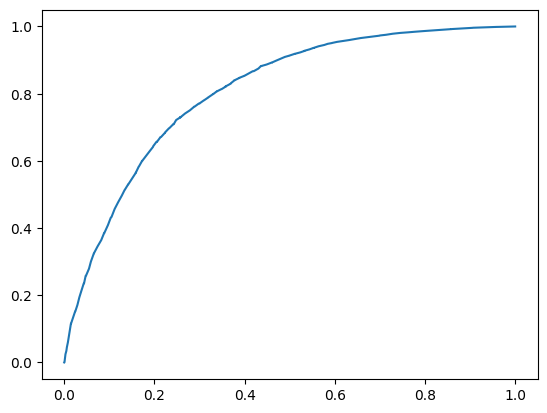

In [ ]:
evaluate_model(rfc, X_train, X_test, y_train, y_test, 'Random Forest')

# n_estimator =1000 Model

Change the n_estimators from 100 to 1000, increment by 100.

In [ ]:
#Create a graph to compare the accuracy based from n_estimators
n_estimators = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
accuracy_list = []

for n in n_estimators:
    rfc = RandomForestClassifier(n_estimators=n)
    rfc.fit(X_train, y_train)
    y_pred = rfc.predict(X_test)
    accuracy = rfc.score(X_test, y_test)
    accuracy_list.append(accuracy)

Create a graph to compare the accuracy based from n_estimators

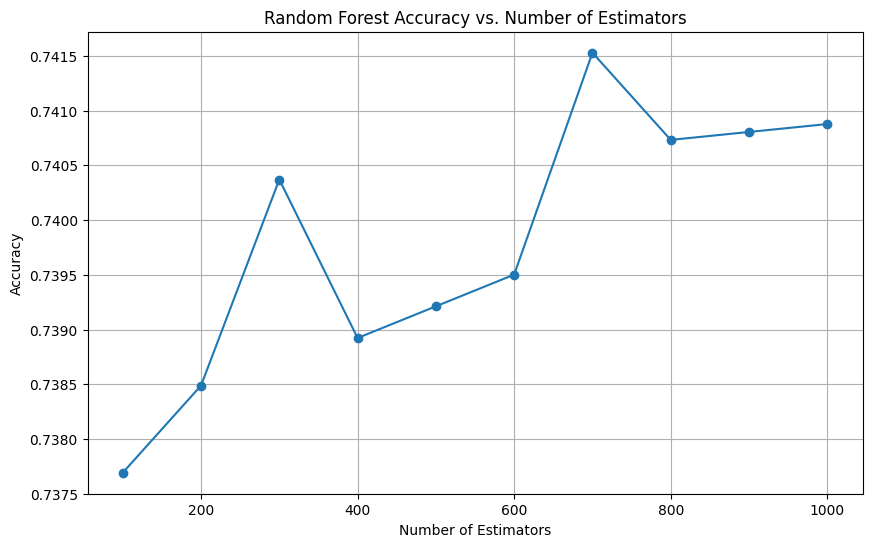

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, accuracy_list, marker='o')
plt.title('Random Forest Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
rfc_700 = RandomForestClassifier(n_estimators=700)
rfc_700.fit(X_train, y_train)

RandomForestClassifier(n_estimators=700)

Results for Random Forest Search
Training Accuracy: 0.9953
Training Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     27237
           1       1.00      0.99      1.00     28008

    accuracy                           1.00     55245
   macro avg       1.00      1.00      1.00     55245
weighted avg       1.00      1.00      1.00     55245

Testing Accuracy: 0.7407
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.70      0.72      6723
           1       0.73      0.78      0.76      7089

    accuracy                           0.74     13812
   macro avg       0.74      0.74      0.74     13812
weighted avg       0.74      0.74      0.74     13812

Confusion Matrix (Test Set) for Random Forest:
[[4686 2037]
 [1544 5545]]
AUC-ROC (Test Set) for Random Forest: 0.8111


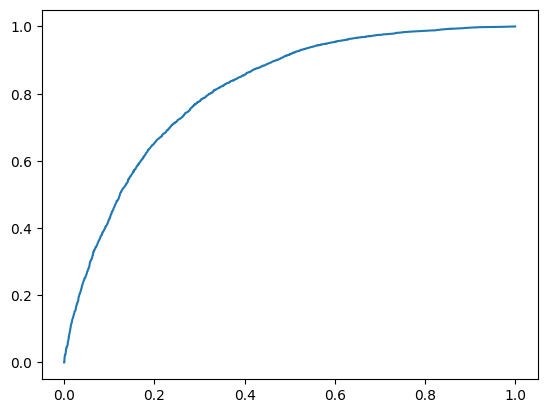

In [ ]:
evaluate_model(rfc_700, X_train, X_test, y_train, y_test, 'Random Forest')

Conclusion

<font color = green> In this activity we learn how Random Forest Classifier works. Throughout this activity we manage  to analyze and gain insight about the loan dataset where we perform RandomForestClassifier(). As we training the model we only got around 84% which is slighty better and our model as shown in the first graph is right skewed and unbalanced interms of  data distribution which is important in modelling since it may affect the performance of our model making it more bias to class with high frequency. Thus, our model shown to be overfitted.

<font color = green> When doing the supplementary, I use a diabetes dataset to perform the random forest. Upon cleaning and visualizing the grapph, I notice that our features have a low correlation in our target columns that can affect our model performance. Even though our data is slightly balance and normaly distributed, we still got a overfitted model, and a low accuracy in testing with roughly 73% which is not acceptable for using in medical prediction. We also got a lot of misclassification which is not good. Therefore we can also conclude that  the relationship of each features to the target is important in performing the model. We also change the number of trees by incrementing by 100. As  we perform the task we saw that n_estimator = 700 got the highest accuracy among the  list of estimator; having an accuracy score of 74.15% on testing. Therefore we can also say that having a large n_estimator isn't always the best for random search classifier.